In [ ]:
from google.colab import drive
try:
  drive.mount('/content/drive', force_remount=True)
  print("Kết nối thành công với gg drive")
except Exception as e:
  print(f"Đã xảy ra lỗi: {e}")


Mounted at /content/drive
Kết nối thành công với gg drive


In [ ]:
import os
import pandas as pd
import numpy as np
import joblib
import warnings
import time
import psutil
from datetime import datetime
import json
import sklearn
import librosa
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from scipy.stats import skew
from tqdm import tqdm
# --- CẤU HÌNH CHÍNH ---


# OUTPUT_DIR = '/content/drive/MyDrive/HK1-20252026/ClassifyStego'


COVER_FOLDER = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq'
STEGO_FOLDER = '/content/drive/MyDrive/HK1-20252026/Steganography/PSR-LSB_AUDIO_2025-11-21_20-41-03/Temp_Stego'
OUTPUT_DIR = '/content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB'

os.makedirs(OUTPUT_DIR, exist_ok=True)


# Các tên file cố định
FEATURES_FILE = os.path.join(OUTPUT_DIR,'features.npz')
MODEL_FILE_SVM = os.path.join(OUTPUT_DIR,'SVM', 'best_svm_model.pkl')
MODEL_FILE_RF = os.path.join(OUTPUT_DIR,'RandomForest', 'best_rf_model.pkl')
MODEL_FILE_LR = os.path.join(OUTPUT_DIR, 'LogisticRegression', 'best_lr_model.pkl')
SCALER_FILE = os.path.join(OUTPUT_DIR,'scaler.pkl')


TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
rpSVM = 'SVM/reportSVM_' + TIMESTAMP
rpRF = 'RandomForest/reportRF_' + TIMESTAMP
rpLR = 'LogisticRegression/reportLR_' + TIMESTAMP

os.makedirs(os.path.join(OUTPUT_DIR, rpSVM), exist_ok=True)
# os.makedirs(os.path.join(OUTPUT_DIR, rpRF), exist_ok=True)
# os.makedirs(os.path.join(OUTPUT_DIR, rpLR), exist_ok=True)

JSON_REPORT_FILE_SVM = os.path.join(OUTPUT_DIR,rpSVM, f'report_{TIMESTAMP}.json')
JSON_REPORT_FILE_SVM_DEFAULT = os.path.join(OUTPUT_DIR,rpSVM, f'report_default_{TIMESTAMP}.json')
GRID_SEARCH_LOG_FILE_SVM = os.path.join(OUTPUT_DIR, rpSVM,f'grid_search_log_{TIMESTAMP}.csv')

JSON_REPORT_FILE_RF = os.path.join(OUTPUT_DIR,rpRF, f'report_{TIMESTAMP}.json')
JSON_REPORT_FILE_RF_DEFAULT = os.path.join(OUTPUT_DIR,rpRF, f'report_default_{TIMESTAMP}.json')
GRID_SEARCH_LOG_FILE_RF = os.path.join(OUTPUT_DIR, rpRF,f'grid_search_log_{TIMESTAMP}.csv')

JSON_REPORT_FILE_LR = os.path.join(OUTPUT_DIR,rpLR, f'report_{TIMESTAMP}.json')
JSON_REPORT_FILE_LR_DEFAULT = os.path.join(OUTPUT_DIR,rpLR, f'report_default_{TIMESTAMP}.json')
GRID_SEARCH_LOG_FILE_LR = os.path.join(OUTPUT_DIR, rpLR,f'grid_search_log_{TIMESTAMP}.csv')

# --- KHỞI TẠO ---
start_time = time.time()
process = psutil.Process(os.getpid())
mem_before = process.memory_info().rss / (1024 * 1024)
log_data = {} # Khởi tạo dictionary để chứa toàn bộ thông tin log
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from scipy.stats import skew, kurtosis
def extract_features(file_path, n_mfcc=80):
    try:
        y, sr = librosa.load(file_path, sr=None, duration=5.0)
        if len(y) < 5 * sr:
            y = np.tile(y, int(np.ceil((5 * sr) / len(y))))
        y = y[:5 * sr]

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_t = mfccs.T

        features = np.hstack([
            np.mean(mfccs_t, axis=0),
            np.std(mfccs_t, axis=0),
            skew(mfccs_t, axis=0),
            kurtosis(mfccs_t, axis=0)
        ])
        return features
    except Exception as e:
        print(f"Lỗi khi xử lý file {file_path}: {e}")
        return None

def load_data_from_audio(cover_folder, stego_folder):
    features, labels, files_to_process = [], [], []
    for root, _, files in os.walk(cover_folder):
        for f in files:
            if f.endswith('.wav'): files_to_process.append({'path': os.path.join(root, f), 'label': 0})
    for root, _, files in os.walk(stego_folder):
        for f in files:
            if f.endswith('.wav'): files_to_process.append({'path': os.path.join(root, f), 'label': 1})

    for file_info in tqdm(files_to_process, desc="Đang xử lý audio"):
        mfccs = extract_features(file_info['path'])
        if mfccs is not None:
            features.append(mfccs); labels.append(file_info['label'])
    return np.array(features), np.array(labels)

if os.path.exists(FEATURES_FILE):
    print(f" Tải dữ liệu đặc trưng từ file '{FEATURES_FILE}'...")
    data = np.load(FEATURES_FILE); X, y = data['features'], data['labels']
else:
    print(f" Không tìm thấy file đặc trưng. Bắt đầu xử lý audio...")
    X, y = load_data_from_audio(COVER_FOLDER, STEGO_FOLDER)
    print(f"Lưu đặc trưng vào file '{FEATURES_FILE}'...")
    np.savez_compressed(FEATURES_FILE, features=X, labels=y)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
# print(f"Số NaN sau khi xử lý: {np.isnan(X).sum()}")

# Lưu thông tin dataset vào log
log_data['dataset_info'] = {
    'total_samples': X.shape[0],
    'num_features': X.shape[1],
    'class_distribution': {
        'cover_0': int(np.sum(y == 0)),
        'stego_1': int(np.sum(y == 1))
    }
}

print(f"\nTổng cộng {X.shape[0]} mẫu dữ liệu sẵn sàng.")


 Tải dữ liệu đặc trưng từ file '/content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/features.npz'...

Tổng cộng 1500 mẫu dữ liệu sẵn sàng.


In [ ]:
# np.savez_compressed(FEATURES_FILE, features=X, labels=y)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
# print(f"Số NaN sau khi xử lý: {np.isnan(X).sum()}")

# Lưu thông tin dataset vào log
log_data['dataset_info'] = {
    'total_samples': X.shape[0],
    'num_features': X.shape[1],
    'class_distribution': {
        'cover_0': int(np.sum(y == 0)),
        'stego_1': int(np.sum(y == 1))
    }
}

print(f"\nTổng cộng {X.shape[0]} mẫu dữ liệu sẵn sàng.")


Tổng cộng 1500 mẫu dữ liệu sẵn sàng.


In [ ]:


# Chia dữ liệu TRƯỚC KHI chuẩn hóa

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Đã chia dữ liệu thành {len(X_train_raw)} mẫu train và {len(X_test_raw)} mẫu test.")

#  Khởi tạo và Fit Scaler CHỈ trên tập huấn luyện
scaler = StandardScaler()
# print("Đang fit scaler CHỈ trên dữ liệu train...")
scaler.fit(X_train_raw)

# Bước 3: Áp dụng phép biến đổi (transform) cho cả hai tập
# print("Đang transform cả hai tập train và test...")
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Bước 4: Lưu scaler đã được huấn luyện
# print("Đang lưu scaler...")
joblib.dump(scaler, SCALER_FILE)

# print("Hoàn tất quá trình chuẩn hóa dữ liệu một cách an toàn.")
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")

Đã chia dữ liệu thành 1050 mẫu train và 450 mẫu test.
Kích thước tập huấn luyện: (1050, 320)
Kích thước tập kiểm thử: (450, 320)


In [ ]:


def run_default_experiment(model_name, estimator, report_file, X_train, y_train, X_test, y_test):
    print("\n" + "="*60)
    print(f"BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: {model_name.upper()}")
    print("="*60)

    log_data = {}
    process = psutil.Process(os.getpid())

    # --- HUẤN LUYỆN VỚI THAM SỐ MẶC ĐỊNH ---
    print(f"\n Huấn luyện mô hình {model_name} với tham số mặc định...")
    mem_before_train = process.memory_info().rss
    start_time_train = time.time()

    estimator.fit(X_train, y_train)

    training_duration = time.time() - start_time_train
    mem_after_train = process.memory_info().rss
    training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)
    print(f"Huấn luyện hoàn tất sau {training_duration:.2f} giây.")

    log_data['training_info'] = {
        'status': 'Trained with default parameters', 'model_class': type(estimator).__name__,
        'training_duration_seconds': round(training_duration, 2),
        'training_memory_increase_mb': round(training_memory_increase_mb, 2),
        'all_model_params': estimator.get_params() # Đã lưu tất cả tham số mặc định
    }

    # --- ĐÁNH GIÁ HIỆU NĂNG ---
    print(f"\n--- Đánh giá hiệu năng mô hình {model_name} (mặc định) ---")

    start_time_predict = time.time()
    y_test_pred = estimator.predict(X_test)
    prediction_duration = time.time() - start_time_predict

    y_train_pred = estimator.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # --- PHẦN THÊM MỚI ---
    print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Train:")
    print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"\nĐộ chính xác trên tập Test: {test_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Test:")
    print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"Thời gian dự đoán trên tập Test: {prediction_duration:.4f} giây")

    # Vẽ ma trận nhầm lẫn
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover (0)', 'Stego (1)'], cmap=plt.cm.Blues)
    plt.title(f"Ma trận nhầm lẫn trên tập Test ({model_name} - Mặc định)")
    plt.show()
    # -----------------------

    log_data['evaluation_results'] = {
        'train_set': {'accuracy': train_accuracy, 'classification_report': classification_report(y_train, y_train_pred, output_dict=True)},
        'test_set': {'accuracy': test_accuracy, 'classification_report': classification_report(y_test, y_test_pred, output_dict=True)},
        'prediction_duration_seconds': round(prediction_duration, 4)
    }

    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False)
    print(f"📝 Đã lưu báo cáo mặc định chi tiết vào file: {report_file}")



def run_experiment(model_name, estimator, param_grid, model_file, report_file, log_file, X_train, y_train, X_test, y_test, scaler, scaler_file):
    print("\n" + "="*60)
    print(f"BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: {model_name.upper()}")
    print("="*60)

    log_data = {}
    process = psutil.Process(os.getpid())

    if os.path.exists(model_file):
        print(f"\n Đã tìm thấy mô hình. Đang tải từ file '{model_file}'...")
        best_model = joblib.load(model_file)
        log_data['training_info'] = {'status': f'Loaded pre-trained model: {type(best_model).__name__}'}
    else:
        print(f"\n Bắt đầu huấn luyện mô hình mới (có tinh chỉnh)...")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        grid_search = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring='accuracy', cv=cv, verbose=2, n_jobs=-1)

        mem_before_train = process.memory_info().rss
        start_time_train = time.time()
        grid_search.fit(X_train, y_train)
        training_duration = time.time() - start_time_train
        mem_after_train = process.memory_info().rss
        training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)

        best_model = grid_search.best_estimator_

        log_data['training_info'] = {
            'status': 'Newly trained model', 'model_class': type(best_model).__name__,
            'best_cv_score': grid_search.best_score_, 'best_params_from_grid': grid_search.best_params_,
            'training_duration_seconds': round(training_duration, 2),
            'training_memory_increase_mb': round(training_memory_increase_mb, 2),
            'all_model_params': best_model.get_params() # <-- ĐÃ CÓ SẴN Ở ĐÂY
        }
        joblib.dump(best_model, model_file)
        pd.DataFrame(grid_search.cv_results_).to_csv(log_file, index=False)
        print(f"Đã lưu mô hình và log GridSearch sau {training_duration:.2f} giây.")

    print(f"\n--- Đánh giá hiệu năng mô hình {model_name} (tinh chỉnh) ---")

    start_time_predict = time.time()
    y_test_pred = best_model.predict(X_test)
    prediction_duration = time.time() - start_time_predict

    y_train_pred = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # --- PHẦN THÊM MỚI ---
    print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Train:")
    print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"\nĐộ chính xác trên tập Test: {test_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Test:")
    print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)']))

    print(f"Thời gian dự đoán trên tập Test: {prediction_duration:.4f} giây")
    # -----------------------

    # Vẽ ma trận nhầm lẫn
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover (0)', 'Stego (1)'], cmap=plt.cm.Blues)
    plt.title(f"Ma trận nhầm lẫn trên tập Test ({model_name} - Tinh chỉnh)")
    plt.show()

    log_data['evaluation_results'] = {
        'train_set': {'accuracy': train_accuracy, 'classification_report': classification_report(y_train, y_train_pred, output_dict=True)},
        'test_set': {'accuracy': test_accuracy, 'classification_report': classification_report(y_test, y_test_pred, output_dict=True)},
        'prediction_duration_seconds': round(prediction_duration, 4)
    }

    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False)
    print(f" Đã lưu báo cáo tinh chỉnh chi tiết vào file: {report_file}")


BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: SVM

⚠️ Huấn luyện mô hình SVM với tham số mặc định...
Huấn luyện hoàn tất sau 0.72 giây.

--- Đánh giá hiệu năng mô hình SVM (mặc định) ---

Độ chính xác trên tập Train: 0.6895
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.78      0.53      0.63       525
   Stego (1)       0.64      0.85      0.73       525

    accuracy                           0.69      1050
   macro avg       0.71      0.69      0.68      1050
weighted avg       0.71      0.69      0.68      1050


Độ chính xác trên tập Test: 0.5000
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.50      0.32      0.39       225
   Stego (1)       0.50      0.68      0.58       225

    accuracy                           0.50       450
   macro avg       0.50      0.50      0.48       450
weighted avg       0.50      0.50      0.48       450

Thời gian dự đoán trên tập Test: 0

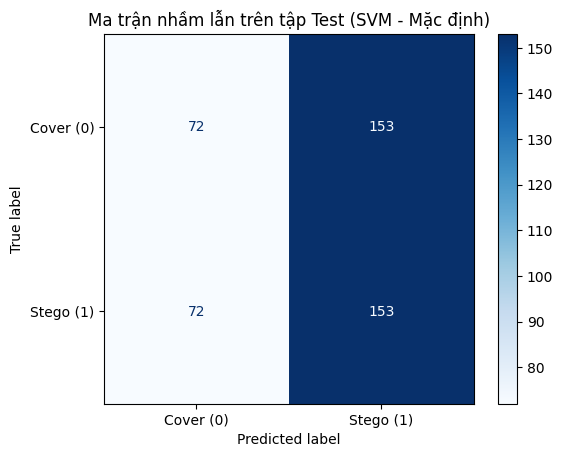

📝 Đã lưu báo cáo mặc định chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/SVM/reportSVM_20251128_152846/report_default_20251128_152846.json

BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: SVM

⚠️ Bắt đầu huấn luyện mô hình mới (có tinh chỉnh)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Đã lưu mô hình và log GridSearch sau 49.49 giây.

--- Đánh giá hiệu năng mô hình SVM (tinh chỉnh) ---

Độ chính xác trên tập Train: 0.6390
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.81      0.36      0.50       525
   Stego (1)       0.59      0.92      0.72       525

    accuracy                           0.64      1050
   macro avg       0.70      0.64      0.61      1050
weighted avg       0.70      0.64      0.61      1050


Độ chính xác trên tập Test: 0.6200
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.79      0.32      0.46       225
 

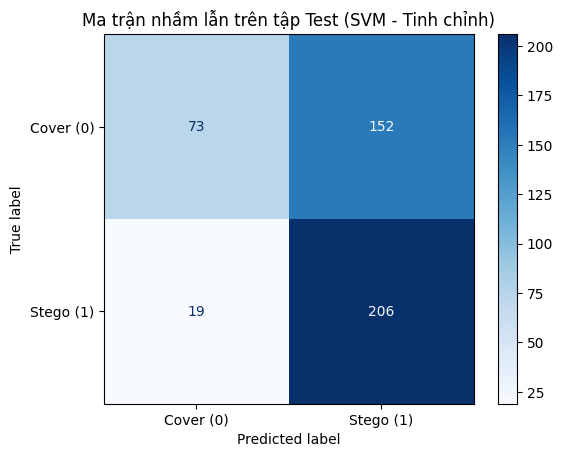

📝 Đã lưu báo cáo tinh chỉnh chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/SVM/reportSVM_20251128_152846/report_20251128_152846.json

🎉 Hoàn tất tất cả các thử nghiệm!


In [ ]:

from sklearn.ensemble import RandomForestClassifier


# --- A. Chạy thử nghiệm cho SVM  ---

run_default_experiment('SVM', SVC(probability=True, random_state=42), JSON_REPORT_FILE_SVM_DEFAULT, X_train, y_train, X_test, y_test)

svm_estimator = SVC(probability=True, random_state=42)

svm_param_grid = {
    'C': [  0.01, 0.1,  1 ],
    'gamma': [  'scale',0.0001,0.01, 0.1,1 ],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
    # ,0.01, 0.1,
}
run_experiment('SVM', svm_estimator, svm_param_grid, MODEL_FILE_SVM, JSON_REPORT_FILE_SVM, GRID_SEARCH_LOG_FILE_SVM, X_train, y_train, X_test, y_test, scaler, SCALER_FILE)




print("\n🎉 Hoàn tất tất cả các thử nghiệm!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: RANDOMFOREST

⚠️ Huấn luyện mô hình RandomForest với tham số mặc định...
Huấn luyện hoàn tất sau 1.47 giây.

--- Đánh giá hiệu năng mô hình RandomForest (mặc định) ---

Độ chính xác trên tập Train: 1.0000
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       1.00      1.00      1.00       600
   Stego (1)       1.00      1.00      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


Độ chính xác trên tập Test: 0.4133
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.41      0.39      0.40       150
   Stego (1)       0.42      0.44      0.43       150

    accuracy                           0.41       300
   macro avg       0.41      0.41      0.41       300
weighted avg       0.41      0.41      0.41       300

Thời gi

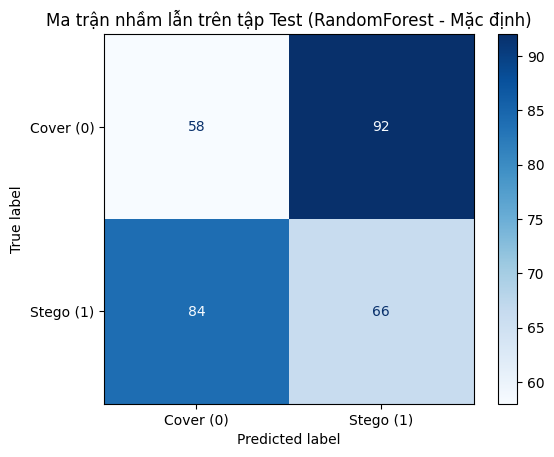

📝 Đã lưu báo cáo mặc định chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/RandomForest/reportRF_20251128_142158/report_default_20251128_142158.json

BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: RANDOMFOREST

✅ Đã tìm thấy mô hình. Đang tải từ file '/content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/RandomForest/best_rf_model.pkl'...

--- Đánh giá hiệu năng mô hình RandomForest (tinh chỉnh) ---

Độ chính xác trên tập Train: 0.7150
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.75      0.65      0.69       600
   Stego (1)       0.69      0.78      0.73       600

    accuracy                           0.71      1200
   macro avg       0.72      0.71      0.71      1200
weighted avg       0.72      0.71      0.71      1200


Độ chính xác trên tập Test: 0.4400
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.42      0.31      0.35       150
   S

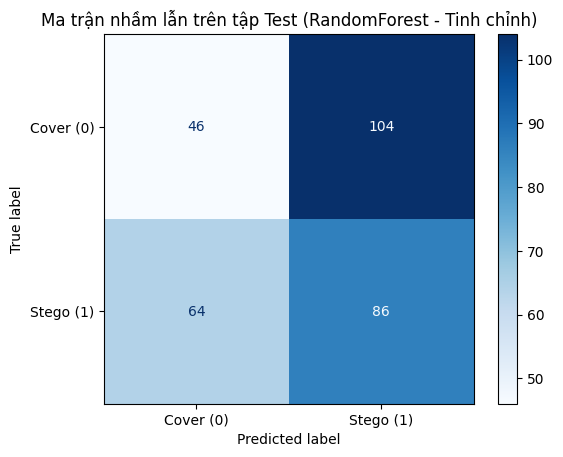

📝 Đã lưu báo cáo tinh chỉnh chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/RandomForest/reportRF_20251128_142158/report_20251128_142158.json


In [ ]:


from sklearn.ensemble import RandomForestClassifier
# --- B. Chạy thử nghiệm cho Random Forest ---

run_default_experiment('RandomForest', RandomForestClassifier(random_state=42, n_jobs=-1), JSON_REPORT_FILE_RF_DEFAULT, X_train, y_train, X_test, y_test)

rf_estimator = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [10 ,20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# rf_estimator = RandomForestClassifier(random_state=42, n_jobs=-1)
# rf_param_grid = {
#     'n_estimators': [100],
#     'max_depth': [5],
#     'min_samples_split': [10],
#     'min_samples_leaf': [20],
#     'max_features': ['sqrt'],
#     'class_weight': ['balanced']
# }
run_experiment('RandomForest', rf_estimator, rf_param_grid, MODEL_FILE_RF, JSON_REPORT_FILE_RF, GRID_SEARCH_LOG_FILE_RF, X_train, y_train, X_test, y_test, scaler, SCALER_FILE)




BẮT ĐẦU QUY TRÌNH MẶC ĐỊNH CHO: LOGISTICREGRESSION

⚠️ Huấn luyện mô hình LogisticRegression với tham số mặc định...
Huấn luyện hoàn tất sau 0.13 giây.

--- Đánh giá hiệu năng mô hình LogisticRegression (mặc định) ---

Độ chính xác trên tập Train: 0.6833
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.70      0.65      0.67       600
   Stego (1)       0.67      0.71      0.69       600

    accuracy                           0.68      1200
   macro avg       0.68      0.68      0.68      1200
weighted avg       0.68      0.68      0.68      1200


Độ chính xác trên tập Test: 0.4533
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (0)       0.45      0.40      0.42       150
   Stego (1)       0.46      0.51      0.48       150

    accuracy                           0.45       300
   macro avg       0.45      0.45      0.45       300
weighted avg       0.45      0.45      0.45 

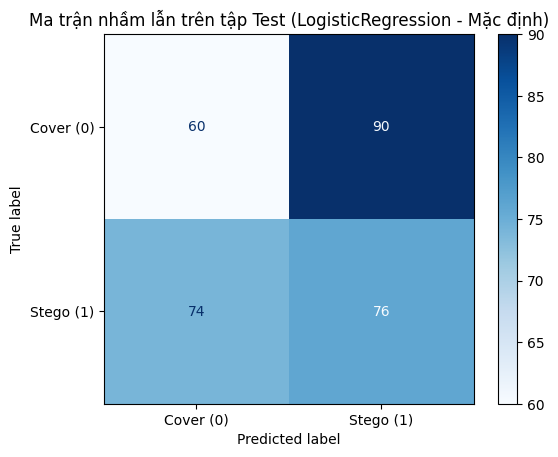

📝 Đã lưu báo cáo mặc định chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/LogisticRegression/reportLR_20251122_071347/report_default_20251122_071347.json

BẮT ĐẦU QUY TRÌNH TINH CHỈNH CHO: LOGISTICREGRESSION

⚠️ Bắt đầu huấn luyện mô hình mới (có tinh chỉnh)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Đã lưu mô hình và log GridSearch sau 372.75 giây.

--- Đánh giá hiệu năng mô hình LogisticRegression (tinh chỉnh) ---

Độ chính xác trên tập Train: 0.6475
Báo cáo chi tiết trên tập Train:
              precision    recall  f1-score   support

   Cover (0)       0.67      0.58      0.62       600
   Stego (1)       0.63      0.71      0.67       600

    accuracy                           0.65      1200
   macro avg       0.65      0.65      0.65      1200
weighted avg       0.65      0.65      0.65      1200


Độ chính xác trên tập Test: 0.5767
Báo cáo chi tiết trên tập Test:
              precision    recall  f1-score   support

   Cover (

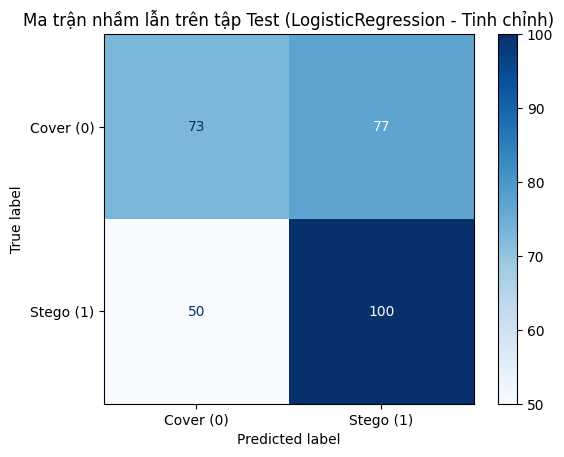

📝 Đã lưu báo cáo tinh chỉnh chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/LogisticRegression/reportLR_20251122_071347/report_20251122_071347.json


In [ ]:


from sklearn.linear_model import LogisticRegression
# --- C. Chạy thử nghiệm cho Logistic Regression  ---

run_default_experiment('LogisticRegression', LogisticRegression(random_state=42, max_iter=2000), JSON_REPORT_FILE_LR_DEFAULT, X_train, y_train, X_test, y_test)

lr_estimator = LogisticRegression(random_state=42, max_iter=5000)
# Thử nghiệm cả 2 loại phạt L1 và L2 với các solver tương ứng
lr_param_grid = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.01, 0.1, 1]
    },
    {
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs', 'saga'],
        'C': [0.01, 0.1, 1, ]
    }
]

# lr_param_grid = [
#     {
#         'penalty': ['l1'],
#         'solver': [ 'saga'],
#         'C': [0.01]
#     }
# ]
run_experiment('LogisticRegression', lr_estimator, lr_param_grid, MODEL_FILE_LR, JSON_REPORT_FILE_LR, GRID_SEARCH_LOG_FILE_LR, X_train, y_train, X_test, y_test, scaler, SCALER_FILE)

In [ ]:
import joblib
import librosa
import numpy as np
from scipy.stats import skew, kurtosis
import warnings
import os

# Bỏ qua các cảnh báo không cần thiết từ librosa
warnings.filterwarnings("ignore", category=FutureWarning)

# ==============================================================================

OUTPUT_DIR = '/content/drive/MyDrive/HK1-20252026/ClassifyStego'
MODEL_TO_USE_PATH = os.path.join(OUTPUT_DIR, 'LSB','SVM', 'best_svm_model.pkl')

)
SCALER_PATH = os.path.join(OUTPUT_DIR,'scaler.pkl')

AUDIO_FILE_PATH = '/content/drive/MyDrive/HK1-20252026/ClassifyStego/data_model/phase/Stego/stego_A Classic Education - NightOwl_vocals.wav'


def extract_features(file_path, n_mfcc=80):
    try:
        y, sr = librosa.load(file_path, sr=None, duration=5.0)
        if len(y) < 5 * sr:
            y = np.tile(y, int(np.ceil((5 * sr) / len(y))))
        y = y[:5 * sr]

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_t = mfccs.T

        features = np.hstack([
            np.mean(mfccs_t, axis=0),
            np.std(mfccs_t, axis=0),
            skew(mfccs_t, axis=0),
            kurtosis(mfccs_t, axis=0)
        ])
        return features
    except Exception as e:
        print(f"Lỗi khi xử lý file {file_path}: {e}")
        return None



def classify_single_file(model_path, scaler_path, audio_path):
    """
    Tải mô hình, xử lý và phân loại một file audio duy nhất.
    """
    print("--- Bắt đầu quy trình phân loại ---")

    # 1. Kiểm tra sự tồn tại của các file cần thiết
    if not os.path.exists(model_path):
        print(f" LỖI: Không tìm thấy file mô hình tại '{model_path}'")
        return
    if not os.path.exists(scaler_path):
        print(f"LỖI: Không tìm thấy file scaler tại '{scaler_path}'")
        return
    if not os.path.exists(audio_path):
        print(f" LỖI: Không tìm thấy file audio tại '{audio_path}'")
        return

    # 2. Tải mô hình và scaler
    print(f" Đang tải mô hình từ: {model_path}")
    model = joblib.load(model_path)
    print(f" Đang tải scaler từ: {scaler_path}")
    scaler = joblib.load(scaler_path)

    # 3. Trích xuất đặc trưng từ file audio
    print(f" Đang trích xuất đặc trưng từ file: {os.path.basename(audio_path)}...")
    features = extract_features(audio_path)

    if features is None:
        print("Không thể trích xuất đặc trưng.")
        return

    # 4. Chuẩn bị dữ liệu cho mô hình
    # Reshape lại thành mảng 2D (vì model mong đợi một danh sách các mẫu)
    features_reshaped = features.reshape(1, -1)

    # Áp dụng scaler đã được huấn luyện
    features_scaled = scaler.transform(features_reshaped)

    # 5. Thực hiện dự đoán
    print("🧠 Đang thực hiện dự đoán...")
    prediction = model.predict(features_scaled)
    probabilities = model.predict_proba(features_scaled)

    # 6. Hiển thị kết quả
    result_label = "Stego (File đã giấu tin)" if prediction[0] == 1 else "Cover (File gốc)"
    confidence = probabilities[0][prediction[0]] * 100

    print("\n--- KẾT QUẢ PHÂN LOẠI ---")
    print(f"File: {os.path.basename(audio_path)}")
    print(f" Dự đoán: {result_label}")
    print(f" Độ tin cậy: {confidence:.2f}%")
    print(f"(Xác suất Cover: {probabilities[0][0]*100:.2f}% | Xác suất Stego: {probabilities[0][1]*100:.2f}%)")

# Chạy hàm chính
classify_single_file(MODEL_TO_USE_PATH, SCALER_PATH, AUDIO_FILE_PATH)

--- Bắt đầu quy trình phân loại ---
✅ Đang tải mô hình từ: /content/drive/MyDrive/HK1-20252026/ClassifyStego/LSB/SVM/best_svm_model.pkl
✅ Đang tải scaler từ: /content/drive/MyDrive/HK1-20252026/ClassifyStego/scaler.pkl
🎵 Đang trích xuất đặc trưng từ file: stego_A Classic Education - NightOwl_vocals.wav...
🧠 Đang thực hiện dự đoán...

--- KẾT QUẢ PHÂN LOẠI ---
File: stego_A Classic Education - NightOwl_vocals.wav
➡️ Dự đoán: Stego (File đã giấu tin)
📈 Độ tin cậy: 66.75%
(Xác suất Cover: 33.25% | Xác suất Stego: 66.75%)
